Этапы:

0. Установка библиотек
1. Распознавание PDF-файлов через PPStructureV3 (лучшие результаты)
2. Разделением документов на БЛОКИ, производится по объекту 'paragraph_title'. Собираем объекты 'formula', 'text', 'paragraph_title'.
3. Извлекаем ключевые слова из объектов 'text'
4. (ВРЕМЕННО УБРАНО) Создаём граф знаний RDFLIB по ключевым словам - блокам - текстам
5. (УБРАНО) Конвертируем формулы из LaTex в MathML (https://math.nist.gov/~BMiller/LaTeXML/)
6. (УБРАНО) Добавляем в индекс BehroozMansouri/TangentCFT. Создаём индекс формула - блок текста.
5. Производим поиск через MathBERT
6. Производим фильтрацию (по графу знаний планируется, сейчас просто сравнение ключевых слов)

How I want to store data (not made now):

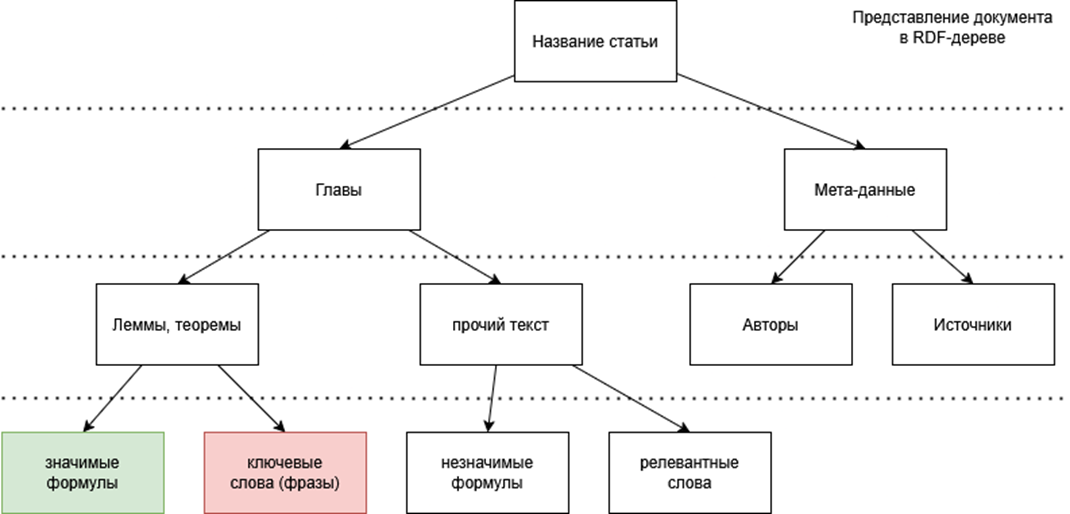

In [3]:
import os
DATA_PATH="../../data/for_rag_2"
DATA_PATH_OCR=os.path.join(DATA_PATH, "ocr_data")
DATA_PATH_TEST="../../data/for_test"
PDF_TEST_NAME="K_Pieri.pdf"
PDF_TEST_NAME_SIM=["a-presentation-of-the-torus-equivariant-quantum-k-theory-ring-of-flag-manifolds-of-type-a-part-ii-quantum-double-grothendieck-polynomials.pdf",
        "QKlectures(MSJ23).pdf",
        "qkf.pdf",
        "S0894-0347-2014-00797-9.pdf",
        "W1605366104.pdf",
    ]

### 0. Установка библиотек

In [ ]:
!pip install paddlepaddle-gpu==3.2.2 -i https://www.paddlepaddle.org.cn/packages/stable/cu126/
!pip3 install rdflib Mathics-omnibus[full] paddleocr[all] keybert sentence-transformers jupyter ipywidgets tqdm

Looking in indexes: https://www.paddlepaddle.org.cn/packages/stable/cu126/
  Using cached https://paddle-whl.bj.bcebos.com/stable/cu126/paddlepaddle-gpu/paddlepaddle_gpu-3.2.2-cp312-cp312-linux_x86_64.whl (1890.5 MB)
  Using cached https://paddle-whl.bj.bcebos.com/stable/cu126/opt-einsum/opt_einsum-3.3.0-py3-none-any.whl (65 kB)
  Using cached https://paddle-whl.bj.bcebos.com/stable/cu126/safetensors/safetensors-0.6.2-cp38-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (485 kB)
  Using cached https://paddle-whl.bj.bcebos.com/stable/cu126/nvidia-cuda-nvrtc-cu12/nvidia_cuda_nvrtc_cu12-12.6.77-py3-none-manylinux2014_x86_64.whl (23.7 MB)
  Using cached https://paddle-whl.bj.bcebos.com/stable/cu126/nvidia-cuda-runtime-cu12/nvidia_cuda_runtime_cu12-12.6.77-py3-none-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (897 kB)
  Using cached https://paddle-whl.bj.bcebos.com/stable/cu126/nvidia-cuda-cupti-cu12/nvidia_cuda_cupti_cu12-12.6.80-py3-none-manylinux2014_x86_64.manylinux_2_17_x86_64.wh

### 1. Распознавание PDF-файлов через PPStructureV3

In [27]:
# https://arxiv.org/pdf/2507.05595
# See https://github.com/PaddlePaddle/PaddleX/pull/4860
from paddleocr import PPStructureV3

pipeline = PPStructureV3(
    use_doc_orientation_classify=False,
    use_doc_unwarping=False,
    use_chart_recognition=False,
    use_seal_recognition=False,
    text_recognition_model_name="cyrillic_PP-OCRv5_mobile_rec",
    lang="ru"
)

Checking connectivity to the model hosters, this may take a while. To bypass this check, set `DISABLE_MODEL_SOURCE_CHECK` to `True`.
/tmp/ipykernel_3896/1986171407.py:5: UserWarning: `lang` and `ocr_version` will be ignored when model names or model directories are not `None`.
  pipeline = PPStructureV3(
/home/alexey/test/mipt_mag_diploma/.venv/lib/python3.12/site-packages/paddle/utils/cpp_extension/extension_utils.py:718: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)
Creating model: ('PP-DocBlockLayout', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/home/alexey/.paddlex/official_models/PP-DocBlockLayout`.
Creating model: ('PP-DocLayout_plus-L', None)
Model files already exist. Using cached files. To redownload, please delete the directory ma

#### OCR part

In [ ]:
from pathlib import Path
import os

PDF_GLOB="*.pdf"
Path(DATA_PATH_OCR).mkdir(exist_ok=True)

In [ ]:
from tqdm.notebook import tqdm
documents_ocr = []
for pdf in tqdm(list(Path(DATA_PATH).glob(PDF_GLOB))):
    name = str(pdf).split(os.path.sep)[-1]
    data_loc = os.path.join(DATA_PATH_OCR, name.split('.')[0])
    #print(f"Processing {name}...")
    output = pipeline.predict(input=str(pdf))
    #res.print()
    #print(f"Done. Saving to {data_loc}...")
    for res in output:
        res.save_to_json(save_path=data_loc)
        res.save_to_markdown(save_path=data_loc)
        res.save_to_img(save_path=data_loc)
    documents_ocr.append(output)

  0%|          | 0/231 [00:00<?, ?it/s]

Resized image size (5352x3828) exceeds max_side_limit of 4000. Resizing to fit within limit.
Resized image size (5424x3694) exceeds max_side_limit of 4000. Resizing to fit within limit.
Resized image size (5448x3684) exceeds max_side_limit of 4000. Resizing to fit within limit.
Resized image size (5356x3712) exceeds max_side_limit of 4000. Resizing to fit within limit.
Resized image size (5230x3668) exceeds max_side_limit of 4000. Resizing to fit within limit.
Resized image size (5424x3668) exceeds max_side_limit of 4000. Resizing to fit within limit.
Resized image size (5308x3784) exceeds max_side_limit of 4000. Resizing to fit within limit.
Resized image size (5308x3784) exceeds max_side_limit of 4000. Resizing to fit within limit.
Resized image size (5402x3884) exceeds max_side_limit of 4000. Resizing to fit within limit.


In [104]:
# Get OCR result for a test file
output = pipeline.predict(input=os.path.join(DATA_PATH_TEST, PDF_TEST_NAME))
for res in output:
    res.save_to_json(save_path=os.path.join(DATA_PATH_OCR, PDF_TEST_NAME.split('.')[0]))
    res.save_to_markdown(save_path=os.path.join(DATA_PATH_OCR, PDF_TEST_NAME.split('.')[0]))
    res.save_to_img(save_path=os.path.join(DATA_PATH_OCR, PDF_TEST_NAME.split('.')[0]))

#### JSON read

In [4]:
from pathlib import Path
import os
import json
def get_doc_ocr(dir_path: Path):
    doc = list()
    name_no_ext = dir_path.name.split('.')[0]
    print(f"Processing {name_no_ext}...")
    json_loc = list(dir_path.glob(f"{name_no_ext}_*_res.json"))
    for it in json_loc:
        with open(it, 'r') as f:
            doc.append(json.load(f))
            doc[-1]['source'] = str(it)
    return doc

In [5]:
# Reread again. It is other part of the pipeline.
documents = []
for dir in list(Path(DATA_PATH_OCR).glob(f"*")):
    if dir.is_file():
        print(f"Skipping file {dir}...")
        continue
    if dir.name == PDF_TEST_NAME.split('.')[0]:
        print(f"Skipping test file {dir}...")
        continue
    doc = get_doc_ocr(dir)
    documents.append(doc)

Processing W4313906264...
Processing W2947403672...
Processing W2058136114...
Processing W2170736098...
Processing W4317037187_2...
Processing W3106399188_2...
Processing W4320023428...
Processing W2120147116...
Processing W4386002119...
Processing W2607439077...
Processing W2007847497...
Processing W3091013140...
Processing W2124087934...
Processing W2147684619...
Processing W4381512361...
Processing W3211598426...
Processing W3150135871_1...
Processing W4283689522...
Processing W3164429027...
Processing a-presentation-of-the-torus-equivariant-quantum-k-theory-ring-of-flag-manifolds-of-type-a-part-ii-quantum-double-grothendieck-polynomials...
Processing W4393038435...
Processing W2160119425...
Processing W4328129846...
Processing W3008950759...
Processing W25036734...
Processing W1812435294...
Processing W4234241455...
Processing W2945080456...
Processing W3207736672...
Processing W2343598444...
Processing W2899232124_2...
Processing W2084703380...
Processing W4287591918...
Processing

In [6]:
# get doc PDF_TEST_NAME
test_doc = get_doc_ocr(Path(os.path.join(DATA_PATH_OCR, PDF_TEST_NAME.split('.')[0])))

Processing K_Pieri...


In [7]:
test_doc

[{'input_path': '../../data/for_test/K_Pieri.pdf',
  'page_index': 14,
  'page_count': 27,
  'width': 1224,
  'height': 1584,
  'model_settings': {'use_doc_preprocessor': True,
   'use_seal_recognition': False,
   'use_table_recognition': True,
   'use_formula_recognition': True,
   'use_chart_recognition': False,
   'use_region_detection': True,
   'format_block_content': False,
   'markdown_ignore_labels': ['number',
    'footnote',
    'header',
    'header_image',
    'footer',
    'footer_image',
    'aside_text']},
  'parsing_res_list': [{'block_label': 'header',
    'block_content': 'A PIERI-TYPE FORMULA FOR THE K-THEORY OF A FLAG MANIFOLD ',
    'block_bbox': [281, 39, 950, 56],
    'block_id': 0,
    'block_order': None},
   {'block_label': 'number',
    'block_content': '15',
    'block_bbox': [1056, 42, 1073, 56],
    'block_id': 1,
    'block_order': None},
   {'block_label': 'text',
    'block_content': 'simply by the formula of Theorem 1.6. The transition formula [11, 15]

### 2. Разделением документов на БЛОКИ, производится по объекту 'paragraph_title'. Собираем объекты 'formula', 'text', 'paragraph_title'.
### 3. Извлекаем ключевые слова из объектов 'text'

In [8]:
class doc_data_blocks:
    pass
class data_block:
    def __init__(self, source_obj: doc_data_blocks):
        self.source_obj = source_obj
        self.text = ""
        self.formulas = list[str]()
        self.keywords = list[str]()
    def __str__(self):
        return f"Block of {self.source_obj.location[0]['input_path']}."
    def __repr__(self):
        return f"Block of {self.source_obj.location[0]['input_path']}."
class doc_data_blocks:
    def __init__(self, location):
        self.location = location
        self.blocks = list[data_block]()
    def __str__(self):
        return f"{self.location[0]['input_path']} with {len(self.blocks)} blocks."

In [9]:
# Based on:
# * https://markaicode.com/extract-keywords-text-transformers-python/
# * https://huggingface.co/google/embeddinggemma-300m

from keybert import KeyBERT
kw_model = KeyBERT('unsloth/embeddinggemma-300m')

def extract_keywords(text, num_keywords=10):
    return kw_model.extract_keywords(text, keyphrase_ngram_range=(1, 2), top_n=num_keywords)

extract_keywords("This is a sample text for keyword extraction using sentence transformers.", num_keywords=5)

[('keyword extraction', 0.6634),
 ('sample text', 0.6561),
 ('sentence transformers', 0.6501),
 ('text keyword', 0.5795),
 ('keyword', 0.5609)]

In [10]:
from tqdm.notebook import tqdm
def process_doc(pages: list[dict]) -> doc_data_blocks:
    x = doc_data_blocks(pages)
    block_str = data_block(x)
    paragraph_title_first_found = False
    previous_block = None
    for page in pages:
        for node in page["parsing_res_list"]:
            # If it paragraph_title, start new block
            if node["block_label"] == "formula":
                block_str.formulas.append(node["block_content"])
            if node["block_label"] == "paragraph_title":
                paragraph_title_first_found = True
                if previous_block == "paragraph_title":
                    block_str.text += f" {node['block_content']}"
                    pass
                else:
                    ## Previous text too small, add to it manually
                    #if len(x.text_blocks) >1 and len(x.text_blocks[-1]) < 100:
                    #    block_str += " "
                    #    block_str += node["block_content"]
                    #else:
                    if block_str.text != "":
                        x.blocks.append(block_str)
                        block_str = data_block(x)
                    block_str.text += node["block_content"]
            elif node["block_label"] == "text":
                # Skip until first paragraph_title met
                if paragraph_title_first_found:
                    block_str.text += f" {node['block_content']}"
            else:
                pass
            previous_block = node["block_content"]
    # Now extract keywords
    for block in tqdm(x.blocks, desc=f"Extracting keywords ({x.location[0]['input_path']})"):
        # 2 words has more info
        keywords = extract_keywords(block.text)
        #print(keywords)
        block.keywords=keywords
    return x

In [11]:
from tqdm.notebook import tqdm
docs_data = list[doc_data_blocks]()
for pages in tqdm(documents):
    docs_data.append(process_doc(pages))

  0%|          | 0/231 [00:00<?, ?it/s]

Extracting keywords (../../data/for_rag_2/W4313906264.pdf):   0%|          | 0/26 [00:00<?, ?it/s]

Extracting keywords (../../data/for_rag_2/W2947403672.pdf):   0%|          | 0/6 [00:00<?, ?it/s]

Extracting keywords (../../data/for_rag_2/W2058136114.pdf):   0%|          | 0/11 [00:00<?, ?it/s]

Extracting keywords (../../data/for_rag_2/W2170736098.pdf):   0%|          | 0/10 [00:00<?, ?it/s]

...

Extracting keywords (../../data/for_rag_2/W4387975065.pdf):   0%|          | 0/10 [00:00<?, ?it/s]

Extracting keywords (../../data/for_rag_2/W2988279279.pdf):   0%|          | 0/10 [00:00<?, ?it/s]

Extracting keywords (../../data/for_rag_2/W3159379906.pdf):   0%|          | 0/8 [00:00<?, ?it/s]

Extracting keywords (../../data/for_rag_2/W4285235314.pdf):   0%|          | 0/9 [00:00<?, ?it/s]

Extracting keywords (../../data/for_rag_2/W4324126587_2.pdf):   0%|          | 0/2 [00:00<?, ?it/s]

In [12]:
test_doc_data = process_doc(test_doc)

Extracting keywords (../../data/for_test/K_Pieri.pdf):   0%|          | 0/11 [00:00<?, ?it/s]

In [13]:
# save it
from joblib import dump, load
if 'docs_data' in locals().keys():
    dump(docs_data, os.path.join(".", "docs_data_blocks.joblib"))
if not 'docs_data' in locals().keys():
    docs_data = load(os.path.join(".", "docs_data_blocks.joblib"))
for x in docs_data[:2]:
    for i in x.blocks:
        print(f"Text len: {len(i.text)}")
        print(f"Formulas len: {len(i.formulas)}")
        print(f"Keywords: {i.keywords}")
        print("-----")

Text len: 4567
Formulas len: 16
Keywords: [('parabolic subgroup', 0.443), ('parabolic subgroups', 0.441), ('subgroup mathbb', 0.4353), ('operatorname f_', 0.4285), ('mathbb theorem', 0.3947), ('j_ mathfrak', 0.3857), ('function mathfrak', 0.3783), ('equivariant', 0.3707), ('mathbb h_', 0.3672), ('compact subgroup', 0.3667)]
-----
Text len: 3088
Formulas len: 8
Keywords: [('subgroup parabolic', 0.4788), ('parabolic subgroups', 0.4734), ('parabolic subgroup', 0.4724), ('symmetric group', 0.4068), ('omega mathfrak', 0.3977), ('mathcal group', 0.3938), ('p_ mathfrak', 0.3849), ('stable mathcal', 0.3835), ('subgroups l_', 0.3782), ('weyl groups', 0.3681)]
-----
Text len: 1625
Formulas len: 5
Keywords: [('parabolic subgroup', 0.4507), ('parabolic subgroups', 0.4491), ('subgroups stable', 0.3988), ('subgroup mathfrak', 0.3935), ('stable parabolic', 0.3796), ('stable proof', 0.375), ('mathfrak mathcal', 0.3662), ('sum_ q_', 0.3467), ('regular semisimple', 0.3459), ('standard parabolic', 0.3321

### 5. Производим поиск

In [14]:
# https://colab.research.google.com/github/GoogleCloudPlatform/vertex-ai-samples/blob/main/notebooks/official/generative_ai/text_embedding_api_semantic_search_with_scann.ipynb#scrollTo=bb3fc5b6c2c3

import pandas as pd

formulas_list = list[dict]()
for doc in docs_data:
    for block in doc.blocks:
        for formula in block.formulas:
            formulas_list.append({
                "formula": formula,
                "block": block
            })
formulas_pd = pd.DataFrame(formulas_list)

In [15]:
formulas_pd.head(10)

,formula,block
0,"\begin{aligned}{\int_{P_{1,H}(F)\backslash H(\...",Block of ../../data/for_rag_2/W4313906264.pdf.
1,"\bigcup_{B\in\mathcal{P}(\widetilde{P}_{0},P_{...",Block of ../../data/for_rag_2/W4313906264.pdf.
2,"\begin{aligned}{\int_{P_{1,H}(F)\backslash H(\...",Block of ../../data/for_rag_2/W4313906264.pdf.
3,"\Phi_{\xi}^{n_{2}x,R}(\widehat{X})=\Phi_{\xi}^...",Block of ../../data/for_rag_2/W4313906264.pdf.
4,G(\mathbb{A})=P(F)\mathfrak{S}_{B}^{P}(\varrho...,Block of ../../data/for_rag_2/W4313906264.pdf.
5,"\mathfrak{S}_{B}^{P}(\varrho_{B},t_{0}):=\varr...",Block of ../../data/for_rag_2/W4313906264.pdf.
6,"A_{B}^{\infty}(P,t_{0}):=\{a\in A_{B}^{\infty}...",Block of ../../data/for_rag_2/W4313906264.pdf.
7,"\mathfrak{S}_{B}^{P}(\varrho_{B},t_{0},T):=\va...",Block of ../../data/for_rag_2/W4313906264.pdf.
8,"A_{B}^{\infty}(P,t_{0},T):=\{a\in A_{B}^{\inft...",Block of ../../data/for_rag_2/W4313906264.pdf.
9,0\subsetneq\langle e_{1}\rangle_{D}\subsetneq\...,Block of ../../data/for_rag_2/W4313906264.pdf.


In [16]:
from sentence_transformers import SentenceTransformer
# https://huggingface.co/tbs17/MathBERT
math_ber_model = SentenceTransformer("tbs17/MathBERT")

No sentence-transformers model found with name tbs17/MathBERT. Creating a new one with mean pooling.


In [17]:
def get_embedding_math(text: str) -> list:
    embeddings = math_ber_model.encode([text])
    return embeddings[0]

In [18]:
# This may take several minutes to complete.
from tqdm.notebook import tqdm
tqdm.pandas()
formulas_pd["embedding"] = formulas_pd["formula"].progress_apply(lambda x: get_embedding_math(x))

  0%|          | 0/13307 [00:00<?, ?it/s]

In [20]:
import scann
import numpy as np

record_count = len(formulas_list)
dataset = np.array([formulas_pd.embedding[i] for i in range(record_count)])

normalized_dataset = dataset / np.linalg.norm(dataset, axis=1)[:, np.newaxis]
# configure ScaNN as a tree - asymmetric hash hybrid with reordering
# anisotropic quantization as described in the paper; see README

# use scann.scann_ops.build() to instead create a TensorFlow-compatible searcher
searcher = (
    scann.scann_ops_pybind.builder(normalized_dataset, 10, "dot_product")
    .tree(
        num_leaves=record_count,
        num_leaves_to_search=record_count,
        training_sample_size=record_count,
    )
    .score_ah(2, anisotropic_quantization_threshold=0.2)
    .reorder(100)
    .build()
)

I0000 00:00:1767102166.058030  131681 partitioner_factory_base.cc:58] Size of sampled dataset for training partition: 13307
W0000 00:00:1767102166.761619  131681 gmm_utils.cc:1026] Could not normalize centroid due to zero norm or empty or zero-weight partition.
I0000 00:00:1767102175.601090  131681 kmeans_tree_partitioner_utils.h:90] PartitionerFactory ran in 9.542994954s.
W0000 00:00:1767102176.345366  131681 gmm_utils.cc:73] All 13307 points are exactly the same. (distances_sum = 0.000000)
W0000 00:00:1767102176.347150  131681 gmm_utils.cc:820] All 13307 points are exactly the same in the partition.


In [21]:
import time

def formula_search(query: str) -> list[tuple[data_block, float]]:
    start = time.time()
    query = get_embedding_math(query)
    neighbors, distances = searcher.search(query, final_num_neighbors=3)
    end = time.time()

    res = list()
    for id, dist in zip(neighbors, distances):
        doc_block = formulas_pd.block[int(id)]
        #print(f"[docid:{id}] [{dist}] [{doc_block}] -- {formulas_pd.formula[int(id)][:125]}...")
        res.append((doc_block, dist))
    #print("Latency (ms):", 1000 * (end - start))
    return res

formula_search("A_{B}^{\infty}(P,t_{0}):=\{a\i")

<>:17: SyntaxWarning: invalid escape sequence '\i'
<>:17: SyntaxWarning: invalid escape sequence '\i'
/tmp/ipykernel_131681/2243932247.py:17: SyntaxWarning: invalid escape sequence '\i'
  formula_search("A_{B}^{\infty}(P,t_{0}):=\{a\i")


[(Block of ../../data/for_rag_2/W4313906264.pdf., np.float32(10.854693)),
 (Block of ../../data/for_rag_2/W4313906264.pdf., np.float32(10.68821)),
 (Block of ../../data/for_rag_2/W4313906264.pdf., np.float32(10.48979))]

In [22]:
import joblib
if 'formulas_pd' in locals().keys():
    joblib.dump(formulas_pd, os.path.join(".", "formulas_pd_math_bert.joblib"))
if not 'formulas_pd' in locals().keys():
    formulas_pd = joblib.load(os.path.join(".", "formulas_pd_math_bert.joblib"))

### 5. Производим поиск

In [23]:
import difflib
from tqdm.notebook import tqdm
def similar_docs(doc_data_in: doc_data_blocks):
    sim_doc_data_blocks = []
    sim_blocks_src_set = set()
    for i1 in tqdm(range(len(doc_data_in.blocks))):
        #print(f"Processing block {i1+1} of {len(doc_data_in.blocks)}")
        block = doc_data_in.blocks[i1]
        for formula in block.formulas:
            sim_res = formula_search(formula)
            for sim_block, prob in sim_res:
                if block.source_obj.location[0]['input_path'] == sim_block.source_obj.location[0]['input_path']:
                    print("Self search detected, skipping.")
                    continue
                similar_words = []
                other_keywords = [word[0] for word in sim_block.keywords]
                for word1 in block.keywords:
                    similar_words += difflib.get_close_matches(word1[0], other_keywords, cutoff=0.8)
                if len(similar_words) == 0:
                    continue
                if sim_block.source_obj not in sim_blocks_src_set:
                    sim_doc_data_blocks.append((sim_block, similar_words, prob))
                    sim_blocks_src_set.add(sim_block.source_obj)
    sim_doc_data_blocks = sorted(sim_doc_data_blocks, key=lambda x: x[2], reverse=True)
    return sim_doc_data_blocks

res = similar_docs(test_doc_data)
found_docs = []
for x in [ x[0].source_obj.location[0]['input_path'] for x in res]:
    found_docs.append(Path(x).name)
    print(f"Similar doc: {Path(x).name}")

  0%|          | 0/11 [00:00<?, ?it/s]

Similar doc: a-presentation-of-the-torus-equivariant-quantum-k-theory-ring-of-flag-manifolds-of-type-a-part-ii-quantum-double-grothendieck-polynomials.pdf
Similar doc: QKlectures(MSJ23).pdf
Similar doc: W2963379837_1.pdf
Similar doc: W4289128375.pdf
Similar doc: W2163253099.pdf
Similar doc: W2290378360.pdf
Similar doc: W4205871165_6.pdf


### 6. Тестируем

In [24]:
import numpy as np

# MRR
def mean_reciprocal_rank(y_true, y_pred):
    reciprocal_ranks = []
    for true_docs, pred_docs in zip(y_true, y_pred):
        rr = 0
        for rank, doc in enumerate(pred_docs, start=1):
            if doc in true_docs:
                rr = 1 / rank
                break
        reciprocal_ranks.append(rr)
    return sum(reciprocal_ranks) / len(reciprocal_ranks)
def ndcg(y_true, y_pred, k=5):
    ndcg_scores = []
    for true_docs, pred_docs in zip(y_true, y_pred):
        pred_docs_k = pred_docs[:k]
        dcg = sum([1 / np.log2(idx + 2) if doc in true_docs else 0 for idx, doc in enumerate(pred_docs_k)])
        ideal_docs_k = true_docs[:k]
        idcg = sum([1 / np.log2(idx + 2) for idx, _ in enumerate(ideal_docs_k)])
        ndcg_scores.append(dcg / idcg if idcg > 0 else 0)
    return np.mean(ndcg_scores)
def recall_precision_at_k(y_true, y_pred, k=5):
    recall_list = []
    precision_list = []
    for true_docs, pred_docs in zip(y_true, y_pred):
        top_k = pred_docs[:k]
        hits = len([doc for doc in top_k if doc in true_docs])
        recall_list.append(hits / len(true_docs) if true_docs else 0)
        precision_list.append(hits / k)
    return np.mean(recall_list), np.mean(precision_list)

# Example usage:
#y_true = [['doc1', 'doc2'], ['doc3']]
#y_pred = [['doc2', 'doc4'], ['doc5']]
#print("nDCG@5:", ndcg(y_true, y_pred))
#will print: nDCG@5: 0.3065735963827292

In [25]:
print(f"MRR {mean_reciprocal_rank(PDF_TEST_NAME_SIM, found_docs)}")
print(f"nDCG {ndcg(PDF_TEST_NAME_SIM, found_docs)}")
print(f"Recall and Precision {recall_precision_at_k(PDF_TEST_NAME_SIM, found_docs)}")

MRR 0.7142857142857143
nDCG 0.6893707059983714
Recall and Precision (np.float64(0.13767420916357084), np.float64(0.72))
